# MRT-3 Passenger Demand Forecasting & Overcrowding Detection


#Install & Import Libraries

In [18]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# MRT-3 operating hours (official: 4:30 AM – 11:40 PM)
MRT3_OPERATING_HOURS = list(range(5, 24))   # 05:00 to 23:00

print(f"TensorFlow : {tf.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"MRT-3 operating hours : {MRT3_OPERATING_HOURS}")
print(" All libraries imported.")


TensorFlow : 2.20.0
Pandas     : 2.2.2
MRT-3 operating hours : [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
 All libraries imported.


# Data Loading

In [19]:
RIDERSHIP_FILE = "/content/2023-25 Ridership (Northbound-Southbound)Mr. Aldrich Orsolino (1).xlsx"

SHEET_CONFIG = {
    "JAN TO DEC 2023": {"year":2023,"nb_rows":list(range(8,30)),"sb_rows":list(range(39,61))},
    "JAN TO DEC 2024": {"year":2024,"nb_rows":list(range(8,30)),"sb_rows":list(range(39,61))},
    "JAN TO DEC 2025": {"year":2025,"nb_rows":list(range(7,30)),"sb_rows":list(range(40,63))},
}
COL_NAMES = [
    "hour",
    "s01_north_exit",     "s02_quezon_entry",   "s02_quezon_exit",
    "s03_kamuning_entry", "s03_kamuning_exit",  "s04_cubao_entry",    "s04_cubao_exit",
    "s05_santolan_entry", "s05_santolan_exit",  "s06_ortigas_entry",  "s06_ortigas_exit",
    "s07_shaw_entry",     "s07_shaw_exit",      "s08_boni_entry",     "s08_boni_exit",
    "s09_guadalupe_entry","s09_guadalupe_exit", "s10_buendia_entry",  "s10_buendia_exit",
    "s11_ayala_entry",    "s11_ayala_exit",     "s12_mag_entry",      "s12_mag_exit",
    "s13_taft_entry",     "balanced_total"
]

# Platform capacity — FOI Annex A (DOTr-MRT3, 31 March 2026)
capacity_df = pd.DataFrame({
    "station_no"  : list(range(1,14)),
    "station_name": ["North Avenue","Quezon Avenue","GMA-Kamuning","Cubao",
                     "Santolan-Annapolis","Ortigas","Shaw Boulevard","Boni Avenue",
                     "Guadalupe","Buendia (Sen. Gil Puyat)","Ayala","Magallanes","Taft Avenue"],
    "platform_capacity_persons": [1141.56,1194.10,1363.72,1746.24,1305.64,
                                   1330.68,1618.04,1416.46,1300.37,1644.00,
                                   1222.00,1201.69,719.12]
})
TOTAL_PLATFORM_CAPACITY = capacity_df["platform_capacity_persons"].sum()

all_sheets_raw = pd.read_excel(RIDERSHIP_FILE, sheet_name=None, header=None, dtype=object)
raw_nb, raw_sb = {}, {}
for sheet_name, config in SHEET_CONFIG.items():
    year = config["year"]; df_s = all_sheets_raw[sheet_name]
    df_nb = df_s.iloc[config["nb_rows"],:].copy(); df_nb.columns=COL_NAMES
    df_nb["year"]=year; df_nb["direction"]="NB"
    df_sb = df_s.iloc[config["sb_rows"],:].copy(); df_sb.columns=COL_NAMES
    df_sb["year"]=year; df_sb["direction"]="SB"
    raw_nb[year]=df_nb.reset_index(drop=True)
    raw_sb[year]=df_sb.reset_index(drop=True)

print(" Step 1 complete")
print(f"   NB records : {sum(len(v) for v in raw_nb.values())}")
print(f"   SB records : {sum(len(v) for v in raw_sb.values())}")
print(f"   Platform capacity table loaded : {len(capacity_df)} stations")
print(f"   Total system platform capacity : {TOTAL_PLATFORM_CAPACITY:,.2f} persons")


 Step 1 complete
   NB records : 67
   SB records : 67
   Platform capacity table loaded : 13 stations
   Total system platform capacity : 17,203.62 persons


# Step 2 — Preprocessing



In [20]:
OPERATING_DAYS = 365
ZERO_THRESHOLD = 500

def parse_hour(h_str):
    return int(str(h_str).strip().upper().replace("H","")) // 100

def clean_sheet(raw_dict):
    frames = []
    station_cols = [c for c in COL_NAMES if c != "hour"]
    for year, df in raw_dict.items():
        df = df.copy()
        df["hour_int"] = df["hour"].apply(parse_hour)
        for col in station_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")
        df[station_cols] = df[station_cols].fillna(0)
        df.rename(columns={"balanced_total":"balanced_total_annual"}, inplace=True)
        df["daily_avg_ridership"] = df["balanced_total_annual"] / OPERATING_DAYS
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

clean_nb = clean_sheet(raw_nb); clean_nb["direction"] = "NB"
clean_sb = clean_sheet(raw_sb); clean_sb["direction"] = "SB"

nb_agg = (clean_nb.groupby(["year","hour_int"])["daily_avg_ridership"]
          .sum().reset_index().rename(columns={"daily_avg_ridership":"nb_daily_avg"}))
sb_agg = (clean_sb.groupby(["year","hour_int"])["daily_avg_ridership"]
          .sum().reset_index().rename(columns={"daily_avg_ridership":"sb_daily_avg"}))

df_combined = pd.merge(nb_agg, sb_agg, on=["year","hour_int"], how="outer").fillna(0)
df_combined["total_daily_ridership"] = df_combined["nb_daily_avg"] + df_combined["sb_daily_avg"]
df_combined = df_combined.sort_values(["year","hour_int"]).reset_index(drop=True)

# ── Keep MRT-3 operating hours ONLY (05:00–23:00)
before = len(df_combined)
df_combined = df_combined[df_combined["hour_int"].isin(MRT3_OPERATING_HOURS)]
df_combined = df_combined[df_combined["total_daily_ridership"] >= ZERO_THRESHOLD]
df_combined = df_combined.reset_index(drop=True)

print(" Step 2 complete — Preprocessing done")
print(f"   Rows before operating-hour filter : {before}")
print(f"   Rows after  operating-hour filter : {len(df_combined)}")
print(f"   Active hours : {sorted(df_combined['hour_int'].unique())}")
print(f"   Ridership range : {df_combined['total_daily_ridership'].min():,.0f}"
      f" – {df_combined['total_daily_ridership'].max():,.0f} pax/day")
print()
print(df_combined[["year","hour_int","nb_daily_avg",
                   "sb_daily_avg","total_daily_ridership"]].head(8).to_string(index=False))


 Step 2 complete — Preprocessing done
   Rows before operating-hour filter : 67
   Rows after  operating-hour filter : 54
   Active hours : [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]
   Ridership range : 2,004 – 33,328 pax/day

 year  hour_int  nb_daily_avg  sb_daily_avg  total_daily_ridership
 2023         5   5992.832877   9505.989041           15498.821918
 2023         6  10801.010959  14064.109589           24865.120548
 2023         7  12180.594521  15050.865753           27231.460274
 2023         8  10234.624658  12847.030137           23081.654795
 2023         9   8664.260274  10643.980822           19308.241096
 2023        10   7502.635616   8732.145205           16234.780822
 2023        11   7606.194521   8767.542466           16373.736986
 2023        12   7816.901370  

#Data Augmentation (60 days per slot)




In [21]:
np.random.seed(SEED)

N_DAYS_PER_SLOT = 60      # doubled from 30 → better generalization
WEEKDAY_FACTOR  = 1.08
WEEKEND_FACTOR  = 0.88
DAILY_NOISE_STD = 0.05
SEASONAL_AMP    = 0.03

df_combined_original = df_combined.copy()
augmented_rows = []

for _, row in df_combined.iterrows():
    year=int(row["year"]); hour=int(row["hour_int"])
    base_val=float(row["total_daily_ridership"])
    nb_ratio=float(row["nb_daily_avg"])/base_val if base_val>0 else 0.5
    sb_ratio=float(row["sb_daily_avg"])/base_val if base_val>0 else 0.5
    for d in range(N_DAYS_PER_SLOT):
        is_weekday    = np.random.random() < (5/7)
        wf            = WEEKDAY_FACTOR if is_weekday else WEEKEND_FACTOR
        noise         = np.random.normal(1.0, DAILY_NOISE_STD)
        seasonal      = 1.0 + SEASONAL_AMP * np.sin(2*np.pi*(d%12)/12)
        val           = max(0, base_val * wf * noise * seasonal)
        augmented_rows.append({
            "year":year,"hour_int":hour,"day_index":d,
            "total_daily_ridership":val,
            "nb_daily_avg":val*nb_ratio,"sb_daily_avg":val*sb_ratio
        })

df_combined = (pd.DataFrame(augmented_rows)
               .sort_values(["year","hour_int","day_index"])
               .reset_index(drop=True))




In [22]:
print(" Step 2B complete — Data Augmentation")
print(f"   Original rows  : {len(df_combined_original)}")
print(f"   Augmented rows : {len(df_combined)}  ({N_DAYS_PER_SLOT} days/slot)")
print(f"   Expansion      : {len(df_combined)/len(df_combined_original):.0f}x")
print()
print("   Mean preservation check:")
print(f"   {'Hour':<8}{'Year':<6}{'Original':>12}{'Aug Mean':>12}{'Aug Std':>10}")
print(f"   {'-'*50}")
for hr,yr in [(7,2023),(12,2024),(17,2025)]:
    orig=df_combined_original[(df_combined_original["year"]==yr)&
                               (df_combined_original["hour_int"]==hr)]["total_daily_ridership"]
    aug =df_combined[(df_combined["year"]==yr)&
                     (df_combined["hour_int"]==hr)]["total_daily_ridership"]
    if len(orig):
        print(f"   {hr:02d}:00   {yr}  {orig.values[0]:>12,.0f}"
              f"  {aug.mean():>12,.0f}  {aug.std():>10,.0f}")

 Step 2B complete — Data Augmentation
   Original rows  : 54
   Augmented rows : 3240  (60 days/slot)
   Expansion      : 60x

   Mean preservation check:
   Hour    Year      Original    Aug Mean   Aug Std
   --------------------------------------------------
   07:00   2023        27,231        27,851       3,360
   12:00   2024        17,274        17,439       1,845
   17:00   2025        33,328        34,869       3,333


#Step 3 — Feature Engineering




In [23]:
df = df_combined.copy()

# Cyclical encoding
df["hour_sin"]  = np.sin(2 * np.pi * df["hour_int"] / 24)
df["hour_cos"]  = np.cos(2 * np.pi * df["hour_int"] / 24)
df["hour_raw"]  = df["hour_int"] / 23.0


# Peak flags (MRT-3 official schedule)

In [24]:
df["is_am_peak"] = df["hour_int"].between(7,  9).astype(int)
df["is_pm_peak"] = df["hour_int"].between(17, 19).astype(int)
df["is_peak"]    = ((df["is_am_peak"]==1)|(df["is_pm_peak"]==1)).astype(int)
df["is_offpeak"] = df["hour_int"].between(9, 16).astype(int)
df["is_night"]   = df["hour_int"].between(19, 22).astype(int)
df["is_morning"] = df["hour_int"].between(5,  6).astype(int)

# Year trend

In [25]:
df["year_trend"] = df["year"].map({2023:0, 2024:1, 2025:2})

# Lag features

In [26]:
df = df.sort_values(["year","day_index","hour_int"]).reset_index(drop=True)
df["lag_1h"]          = df["total_daily_ridership"].shift(1)
df["lag_2h"]          = df["total_daily_ridership"].shift(2)
df["rolling_mean_3h"] = df["total_daily_ridership"].shift(1).rolling(3).mean()
df.dropna(subset=["lag_1h","lag_2h","rolling_mean_3h"], inplace=True)
df.reset_index(drop=True, inplace=True)

FEATURE_COLS = [
    "hour_sin","hour_cos","hour_raw",
    "is_am_peak","is_pm_peak","is_peak","is_offpeak","is_night","is_morning",
    "year_trend","lag_1h","lag_2h","rolling_mean_3h"
]
TARGET_COL = "total_daily_ridership"

feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()
df[FEATURE_COLS]       = feature_scaler.fit_transform(df[FEATURE_COLS])
df["ridership_scaled"] = target_scaler.fit_transform(df[[TARGET_COL]]).flatten()

In [27]:
print(" Step 3 complete — Feature Engineering")
print(f"   Total features : {len(FEATURE_COLS)}")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"   {i:>2}. {f}")
print(f"\n   Rows after lag-drop : {len(df)}")
print(f"   Scaled range        : {df['ridership_scaled'].min():.4f} – {df['ridership_scaled'].max():.4f}")

 Step 3 complete — Feature Engineering
   Total features : 13
    1. hour_sin
    2. hour_cos
    3. hour_raw
    4. is_am_peak
    5. is_pm_peak
    6. is_peak
    7. is_offpeak
    8. is_night
    9. is_morning
   10. year_trend
   11. lag_1h
   12. lag_2h
   13. rolling_mean_3h

   Rows after lag-drop : 3237
   Scaled range        : 0.0000 – 1.0000


# Step 4 — Sequence Building (Direct Multi-Output)




In [28]:
LOOKBACK = 5
HORIZON  = 24

ALL_COLS      = FEATURE_COLS + ["ridership_scaled"]
ridership_idx = len(ALL_COLS) - 1

train_df  = df[df["year"].isin([2023,2024])].reset_index(drop=True)
test_df   = df[df["year"]==2025].reset_index(drop=True)
train_arr = train_df[ALL_COLS].values
test_arr  = test_df[ALL_COLS].values

def build_sequences_direct(data, lookback, horizon, target_idx):
    """
    Direct multi-output sliding window.
    X : (samples, lookback, n_features)
    y : (samples, horizon) — all 24 future steps as simultaneous targets
    """
    X, y = [], []
    for i in range(lookback, len(data) - horizon + 1):
        X.append(data[i-lookback:i, :])
        y.append(data[i:i+horizon, target_idx])
    return np.array(X), np.array(y)

X_train, y_train = build_sequences_direct(train_arr, LOOKBACK, HORIZON, ridership_idx)
X_test,  y_test  = build_sequences_direct(test_arr,  LOOKBACK, HORIZON, ridership_idx)

In [29]:
print(" Step 4 complete — Sequences built")
print(f"   X_train : {X_train.shape}  (samples, lookback=5, features=14)")
print(f"   y_train : {y_train.shape}  (samples, horizon=24)")
print(f"   X_test  : {X_test.shape}")
print(f"   y_test  : {y_test.shape}")


 Step 4 complete — Sequences built
   X_train : (2129, 5, 14)  (samples, lookback=5, features=14)
   y_train : (2129, 24)  (samples, horizon=24)
   X_test  : (1052, 5, 14)
   y_test  : (1052, 24)



# Step 5 — BiLSTM Model




In [30]:
N_FEATURES = X_train.shape[2]

model = Sequential([
    Input(shape=(LOOKBACK, N_FEATURES)),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(HORIZON)
], name="BiLSTM_MRT3_v3")




In [31]:
model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
model.summary()

Model: "BiLSTM_MRT3_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 5, 256)         │       146,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,640 (920.47 KB)

 Trainable params: 235,640 (920.47 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                     patience=7, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)
print(f"\n Training complete — Best epoch: {np.argmin(history.history['val_loss'])+1}")


Epoch 1/150
107/107 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0539 - mae: 0.1735 - val_loss: 0.0218 - val_mae: 0.1147 - learning_rate: 0.0010
Epoch 2/150
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0179 - mae: 0.1041 - val_loss: 0.0116 - val_mae: 0.0850 - learning_rate: 0.0010
Epoch 3/150
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0112 - mae: 0.0836 - val_loss: 0.0073 - val_mae: 0.0684 - learning_rate: 0.0010
Epoch 4/150
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0087 - mae: 0.0739 - val_loss: 0.0062 - val_mae: 0.0642 - learning_rate: 0.0010
Epoch 5/150
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0076 - mae: 0.0693 - val_loss: 0.0055 - val_mae: 0.0605 - learning_rate: 0.0010
Epoch 6/150
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0067 - mae: 0.0654 - val_loss: 0.0056 - val_mae: 0.0617 - learning_rate: 0.0010
Epoch 7/150
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0063 - mae: 0.0633 - val_loss: 0.0051 - val_mae: 0.0588 - learning_rate:

#Training Curves

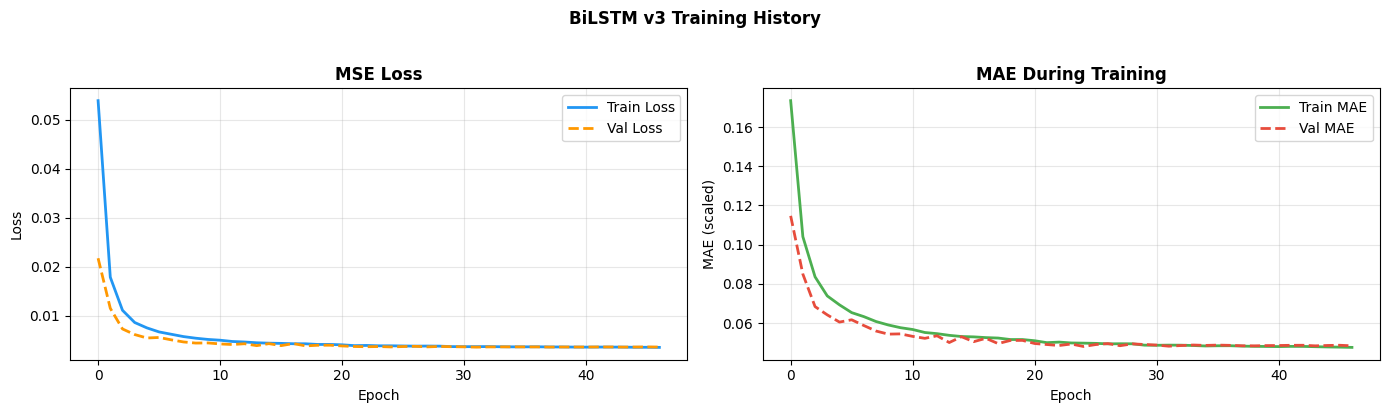

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history["loss"],     label="Train Loss", color="#2196F3", lw=2)
axes[0].plot(history.history["val_loss"], label="Val Loss",   color="#FF9800", lw=2, ls="--")
axes[0].set_title("MSE Loss", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["mae"],     label="Train MAE", color="#4CAF50", lw=2)
axes[1].plot(history.history["val_mae"], label="Val MAE",   color="#e74c3c", lw=2, ls="--")
axes[1].set_title("MAE During Training", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (scaled)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("BiLSTM v3 Training History", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("step5_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


#Step 6 — Model Evaluation




In [34]:
#Predict
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred_actual = target_scaler.inverse_transform(
    y_pred_scaled.reshape(-1,1)).reshape(y_pred_scaled.shape)
y_true_actual = target_scaler.inverse_transform(
    y_test.reshape(-1,1)).reshape(y_test.shape)

yp = y_pred_actual.flatten()
yt = y_true_actual.flatten()

# Remove near-zero for stable metrics

In [35]:
mask   = yt > 100
yp_m   = yp[mask]; yt_m = yt[mask]
mae   = mean_absolute_error(yt_m, yp_m)
rmse  = np.sqrt(mean_squared_error(yt_m, yp_m))
smape = np.mean(2*np.abs(yt_m-yp_m)/(np.abs(yt_m)+np.abs(yp_m)+1e-8))*100

peak_steps = [2,3,4,12,13,14]   # approximate positions of peak hours in horizon
yp_peak = y_pred_actual[:, peak_steps].flatten()
yt_peak = y_true_actual[:, peak_steps].flatten()
mae_peak = mean_absolute_error(yt_peak, yp_peak)

In [37]:
print("=" * 58)
print("  MODEL EVALUATION — Test Set (2025)")
print("=" * 58)
print(f"  MAE   (all hours)  : {mae:>10,.2f}  passengers/day")
print(f"  MAE   (peak only)  : {mae_peak:>10,.2f}  passengers/day  ← key metric")
print(f"  RMSE               : {rmse:>10,.2f}  passengers/day")
print(f"  SMAPE              : {smape:>9.2f}%  (0–200% scale)")
print("=" * 58)
print()


  MODEL EVALUATION — Test Set (2025)
  MAE   (all hours)  :   2,089.52  passengers/day
  MAE   (peak only)  :   2,089.83  passengers/day  ← key metric
  RMSE               :   2,609.78  passengers/day
  SMAPE              :     14.27%  (0–200% scale)



#Actual vs Predicted — Test Sequences

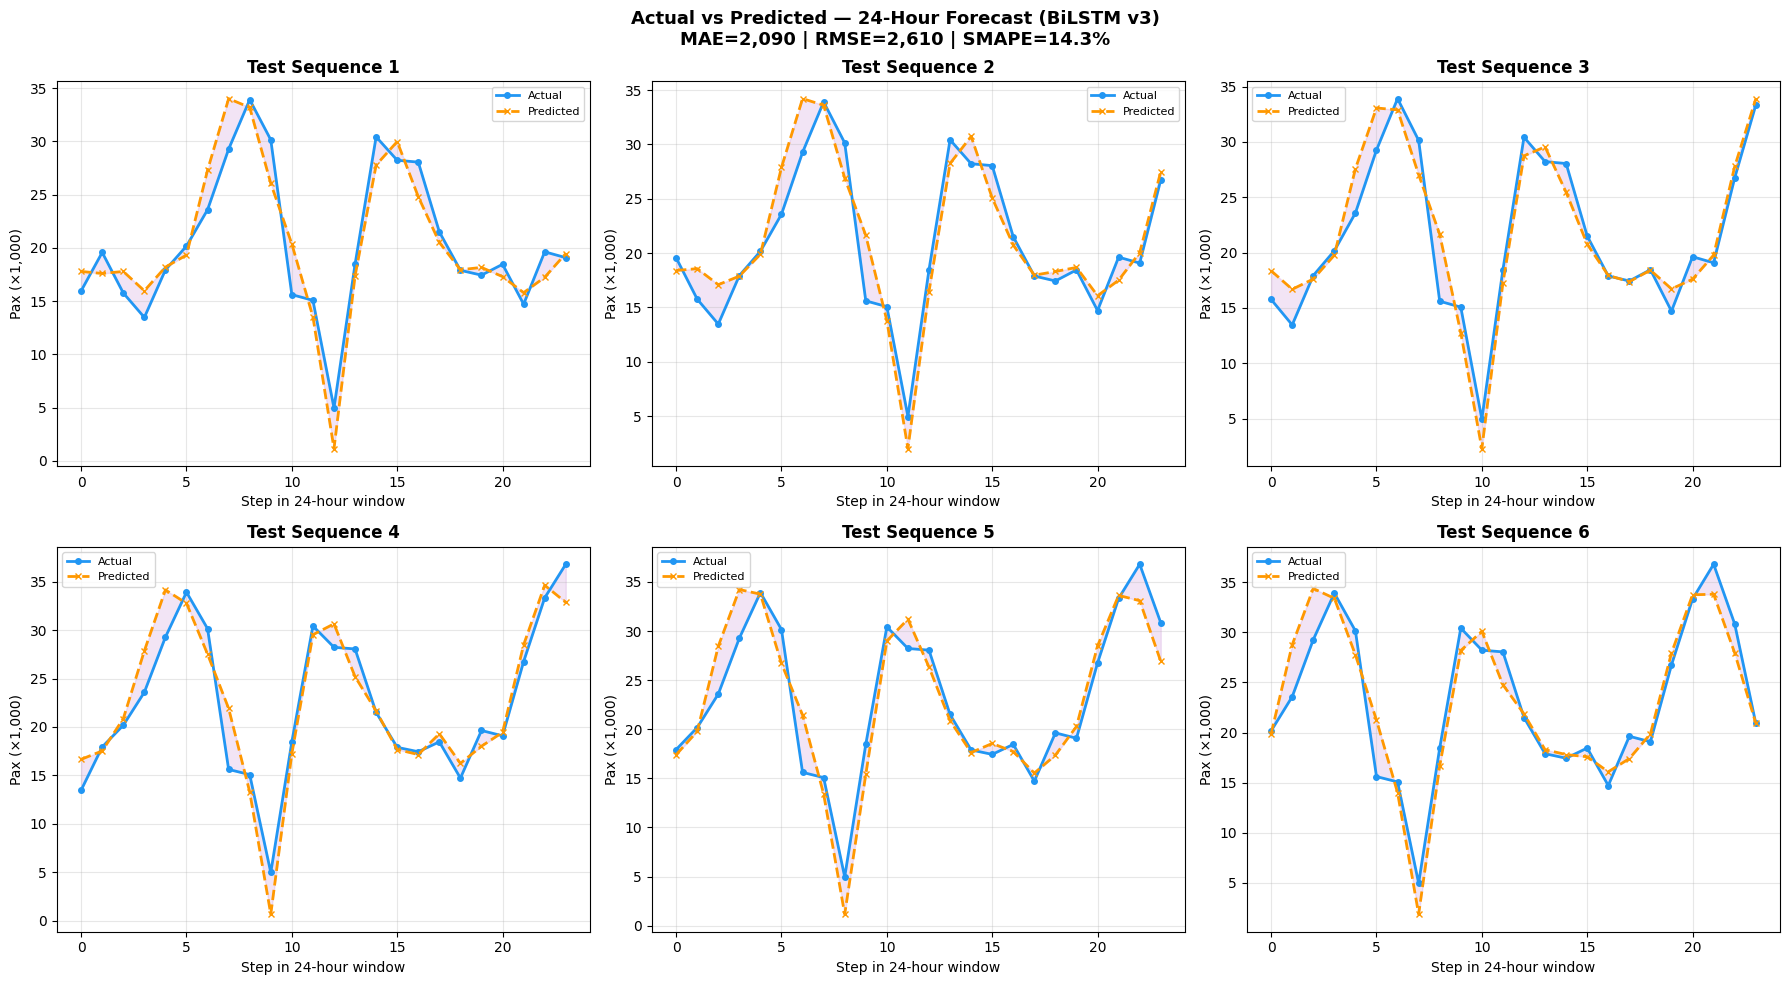

 Saved → step6_actual_vs_predicted.png


In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(min(6, len(y_true_actual))):
    ax = axes[i]
    ax.plot(range(24), y_true_actual[i]/1000, label="Actual",
            color="#2196F3", lw=2, marker="o", ms=4)
    ax.plot(range(24), y_pred_actual[i]/1000, label="Predicted",
            color="#FF9800", lw=2, marker="x", ms=4, ls="--")
    ax.fill_between(range(24), y_true_actual[i]/1000, y_pred_actual[i]/1000,
                    alpha=0.12, color="#9C27B0")
    ax.set_title(f"Test Sequence {i+1}", fontweight="bold")
    ax.set_xlabel("Step in 24-hour window")
    ax.set_ylabel("Pax (×1,000)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f"Actual vs Predicted — 24-Hour Forecast (BiLSTM v3)\n"
             f"MAE={mae:,.0f} | RMSE={rmse:,.0f} | SMAPE={smape:.1f}%",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("step6_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved → step6_actual_vs_predicted.png")


In [39]:
import pickle
model.save("mrt3_bilstm_v3_model.keras")
with open("feature_scaler.pkl","wb") as f: pickle.dump(feature_scaler,f)
with open("target_scaler.pkl", "wb") as f: pickle.dump(target_scaler, f)
print(" Model saved  → mrt3_bilstm_v3_model.keras")
print(" Scalers saved → feature_scaler.pkl, target_scaler.pkl")


 Model saved  → mrt3_bilstm_v3_model.keras
 Scalers saved → feature_scaler.pkl, target_scaler.pkl


# Step 7 — 24-Hour Forecast (Anchored to Next Operating Day)




In [40]:
# Anchor forecast to start at 05:00 (first MRT-3 operating hour)
FORECAST_START_HOUR = 5   # 05:00 AM
forecast_hours = [(FORECAST_START_HOUR + i) % 24 for i in range(HORIZON)]

# Single forward pass — direct multi-output, no recursion

In [41]:
seed_window = test_arr[-LOOKBACK:].reshape(1, LOOKBACK, len(ALL_COLS))
pred_scaled = model.predict(seed_window, verbose=0)[0]
pred_actual = target_scaler.inverse_transform(
    pred_scaled.reshape(-1,1)).flatten()

forecast_df = pd.DataFrame({
    "forecast_step"                : range(1, 25),
    "hour_of_day"                  : forecast_hours,
    "hour_label"                   : [f"{h:02d}:00" for h in forecast_hours],
    "is_operating_hour"            : [h in MRT3_OPERATING_HOURS for h in forecast_hours],
    "predicted_daily_avg_ridership": pred_actual
})




In [42]:
print("Step 7 complete — 24-hour forecast (anchored to 05:00)")
print()
print(forecast_df[["forecast_step","hour_label","is_operating_hour",
                   "predicted_daily_avg_ridership"]].to_string(index=False))

Step 7 complete — 24-hour forecast (anchored to 05:00)

 forecast_step hour_label  is_operating_hour  predicted_daily_avg_ridership
             1      05:00               True                   16645.544922
             2      06:00               True                   27809.035156
             3      07:00               True                   30514.082031
             4      08:00               True                   25617.345703
             5      09:00               True                   20644.556641
             6      10:00               True                   16932.541016
             7      11:00               True                   17999.941406
             8      12:00               True                   18145.013672
             9      13:00               True                   16065.566406
            10      14:00               True                   17607.580078
            11      15:00               True                   19688.476562
            12      16:00       

# Step 8 — Overcrowding Detection



In [43]:
PAX_PER_CAR           = 394
PAX_3CAR              = PAX_PER_CAR * 3    # 1,182
PAX_4CAR              = PAX_PER_CAR * 4    # 1,576
FOUR_CAR_COUNT        = 3
THREE_CAR_COUNT       = 16
SYSTEM_HOURLY_CAPACITY = (FOUR_CAR_COUNT*PAX_4CAR + THREE_CAR_COUNT*PAX_3CAR)  # 23,640
THRESHOLD_NORMAL   = 0.65 * SYSTEM_HOURLY_CAPACITY   # 15,366
THRESHOLD_MODERATE = 0.90 * SYSTEM_HOURLY_CAPACITY   # 21,276

def classify_overcrowding(pax, is_operating):
    if not is_operating:
        return "System Closed", 0.0
    pct = pax / SYSTEM_HOURLY_CAPACITY * 100
    if   pax < THRESHOLD_NORMAL:   return "Normal",   pct
    elif pax < THRESHOLD_MODERATE: return "Moderate", pct
    else:                          return "Critical",  pct

statuses, utils = [], []
for _, row in forecast_df.iterrows():
    s, u = classify_overcrowding(
        row["predicted_daily_avg_ridership"],
        row["is_operating_hour"])
    statuses.append(s); utils.append(round(u,2))

forecast_df["overcrowding_status"]      = statuses
forecast_df["capacity_utilization_pct"] = utils
forecast_df["is_overcrowded"] = forecast_df["overcrowding_status"].map(
    {"Critical":"Overcrowded","Moderate":"Not Overcrowded",
     "Normal":"Not Overcrowded","System Closed":"N/A"})


In [45]:
print(" Capacity Thresholds (DOTr-MRT3 official)")
print(f"   Pax per car              : {PAX_PER_CAR}")
print(f"   System hourly capacity   : {SYSTEM_HOURLY_CAPACITY:,}")
print(f"   Normal  (<65%)           : {THRESHOLD_NORMAL:,.0f}")
print(f"   Moderate (65–90%)        : {THRESHOLD_MODERATE:,.0f}")
print()
print(" Step 8 complete")
print()
print(forecast_df[["forecast_step","hour_label","predicted_daily_avg_ridership",
                   "capacity_utilization_pct","overcrowding_status",
                   "is_overcrowded"]].to_string(index=False))

 Capacity Thresholds (DOTr-MRT3 official)
   Pax per car              : 394
   System hourly capacity   : 23,640
   Normal  (<65%)           : 15,366
   Moderate (65–90%)        : 21,276

 Step 8 complete

 forecast_step hour_label  predicted_daily_avg_ridership  capacity_utilization_pct overcrowding_status  is_overcrowded
             1      05:00                   16645.544922                     70.41            Moderate Not Overcrowded
             2      06:00                   27809.035156                    117.64            Critical     Overcrowded
             3      07:00                   30514.082031                    129.08            Critical     Overcrowded
             4      08:00                   25617.345703                    108.36            Critical     Overcrowded
             5      09:00                   20644.556641                     87.33            Moderate Not Overcrowded
             6      10:00                   16932.541016                     71.

#24-Hour Overcrowding Forecast Chart

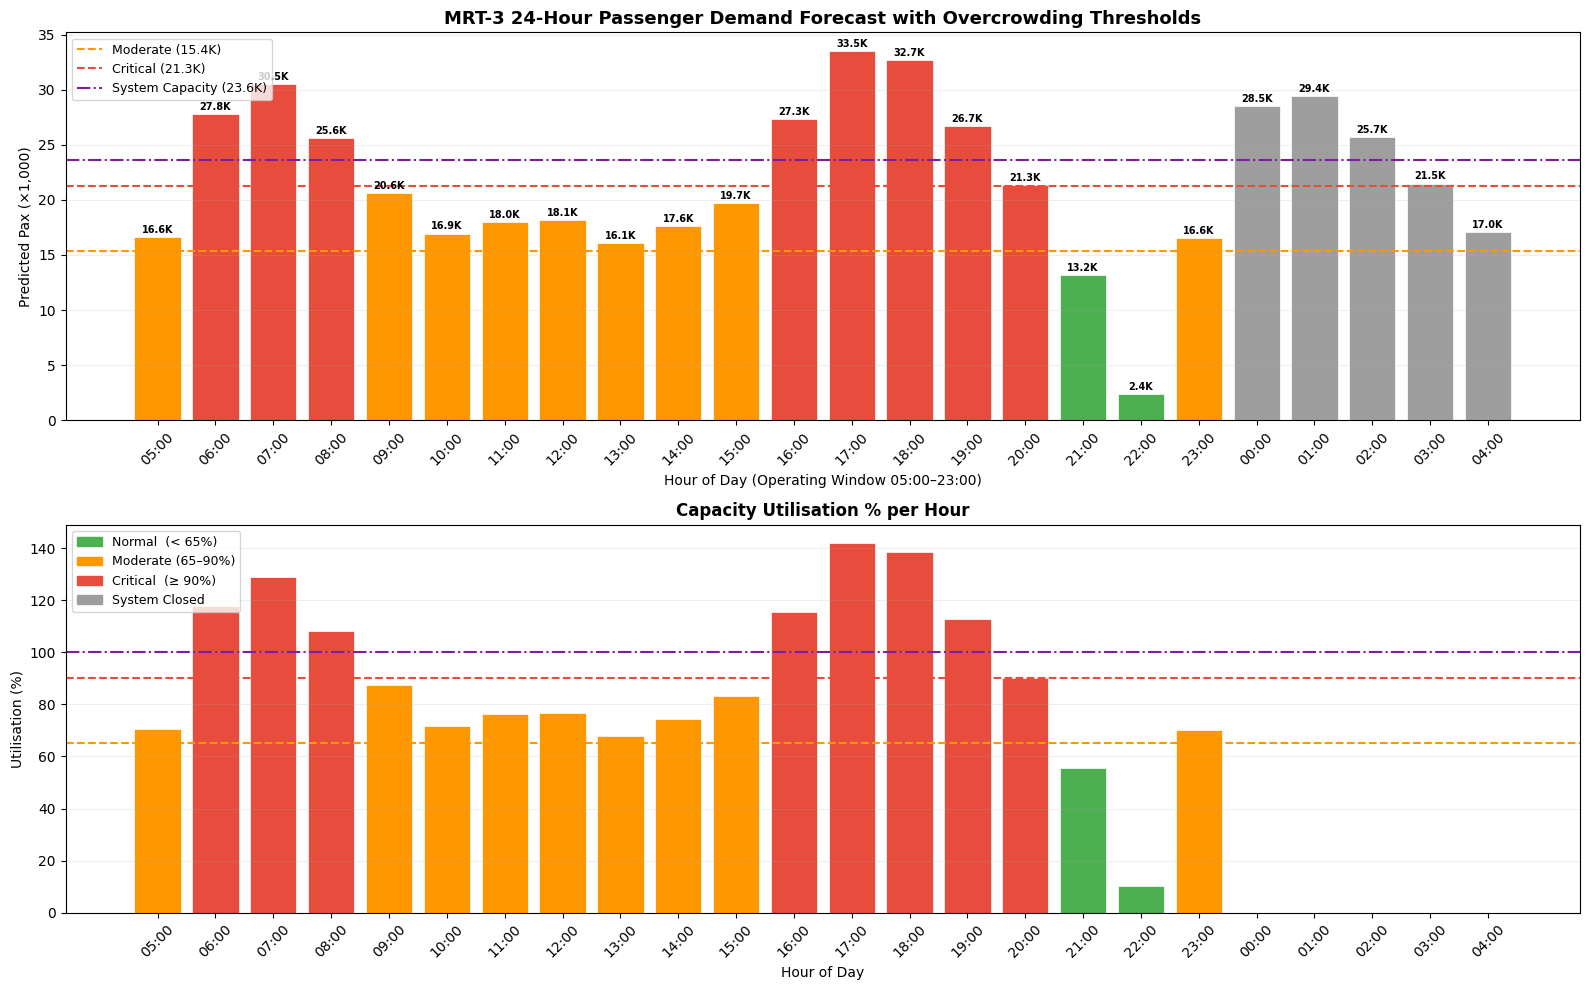

 Saved → step8_overcrowding_forecast.png


In [46]:
cmap = {"Normal":"#4CAF50","Moderate":"#FF9800",
        "Critical":"#e74c3c","System Closed":"#9E9E9E"}
bar_colors = [cmap[s] for s in forecast_df["overcrowding_status"]]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax1 = axes[0]
bars = ax1.bar(forecast_df["hour_label"],
               forecast_df["predicted_daily_avg_ridership"]/1000,
               color=bar_colors, edgecolor="white", lw=0.5)
ax1.axhline(THRESHOLD_NORMAL/1000,   color="#FF9800", ls="--", lw=1.5,
            label=f"Moderate ({THRESHOLD_NORMAL/1000:.1f}K)")
ax1.axhline(THRESHOLD_MODERATE/1000, color="#e74c3c", ls="--", lw=1.5,
            label=f"Critical ({THRESHOLD_MODERATE/1000:.1f}K)")
ax1.axhline(SYSTEM_HOURLY_CAPACITY/1000, color="#7B1FA2", ls="-.", lw=1.5,
            label=f"System Capacity ({SYSTEM_HOURLY_CAPACITY/1000:.1f}K)")
for bar, val in zip(bars, forecast_df["predicted_daily_avg_ridership"]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f"{val/1000:.1f}K", ha="center", va="bottom", fontsize=7, fontweight="bold")
ax1.set_title("MRT-3 24-Hour Passenger Demand Forecast with Overcrowding Thresholds",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Hour of Day (Operating Window 05:00–23:00)")
ax1.set_ylabel("Predicted Pax (×1,000)")
ax1.legend(loc="upper left", fontsize=9)
ax1.tick_params(axis="x", rotation=45); ax1.grid(True, alpha=0.2, axis="y")

ax2 = axes[1]
util_plot = [u if u > 0 else 0 for u in forecast_df["capacity_utilization_pct"]]
ax2.bar(forecast_df["hour_label"], util_plot, color=bar_colors,
        edgecolor="white", lw=0.5)
ax2.axhline(65,  color="#FF9800", ls="--", lw=1.5, label="65% Moderate")
ax2.axhline(90,  color="#e74c3c", ls="--", lw=1.5, label="90% Critical")
ax2.axhline(100, color="#7B1FA2", ls="-.", lw=1.5, label="100% At Capacity")
ax2.set_title("Capacity Utilisation % per Hour", fontsize=12, fontweight="bold")
ax2.set_xlabel("Hour of Day"); ax2.set_ylabel("Utilisation (%)")
ax2.legend(loc="upper left", fontsize=9)
ax2.tick_params(axis="x", rotation=45); ax2.grid(True, alpha=0.2, axis="y")

from matplotlib.patches import Patch
legend_patches = [
    Patch(color="#4CAF50", label="Normal  (< 65%)"),
    Patch(color="#FF9800", label="Moderate (65–90%)"),
    Patch(color="#e74c3c", label="Critical  (≥ 90%)"),
    Patch(color="#9E9E9E", label="System Closed"),
]
ax2.legend(handles=legend_patches, loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("step8_overcrowding_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved → step8_overcrowding_forecast.png")


##  Step 9 — Operational Suggestions

In [48]:
def suggest_operation(status, util_pct):
    if status == "System Closed":
        return "🔒 System not operating at this hour. No action required."
    elif status == "Normal":
        return (" Standard operations. Maintain current train frequency "
                "and headway. No additional intervention required.")
    elif status == "Moderate":
        return (f"⚠️  MODERATE CROWDING ({util_pct:.1f}%). "
                "Action: Deploy 4-car train sets. "
                "Increase platform staff for crowd flow management. "
                "Pre-position additional trains at depot.")
    else:
        hw = "3.0 min" if util_pct >= 100 else "3.5 min"
        return (f" CRITICAL OVERCROWDING ({util_pct:.1f}%). "
                f"Action 1 — Reduce headway to {hw}. "
                "Action 2 — Deploy ALL available 4-car train sets immediately. "
                "Action 3 — Activate crowd management protocol. "
                "Action 4 — Coordinate platform entry with station staff. "
                "Action 5 — Issue passenger advisory on displays and app.")

forecast_df["operational_suggestion"] = forecast_df.apply(
    lambda r: suggest_operation(r["overcrowding_status"],
                                r["capacity_utilization_pct"]), axis=1)

print("="*80)
print(f"  MRT-3   24-HOUR OPERATIONAL FORECAST REPORT (BiLSTM v3)")
print(f"  System Hourly Capacity : {SYSTEM_HOURLY_CAPACITY:,} passengers")
print("="*80)
counts = forecast_df["overcrowding_status"].value_counts()
print("\n  Summary:")
for status, count in counts.items():
    icon={"Normal":"🟢","Moderate":"🟡","Critical":"🔴","System Closed":"⚫"}.get(status,"•")
    print(f"    {icon} {status:<14} : {count:>2} hours")
print("\n"+"-"*80)
for _, row in forecast_df.iterrows():
    icon={"Normal":"🟢","Moderate":"🟡","Critical":"🔴","System Closed":"⚫"}.get(
        row["overcrowding_status"],"•")
    print(f"\n  Hour {row['forecast_step']:>2} | {row['hour_label']} | "
          f"{row['predicted_daily_avg_ridership']:>8,.0f} pax | "
          f"Util: {row['capacity_utilization_pct']:>5.1f}% | "
          f"{icon} {row['overcrowding_status']}")
    print(f"  → {row['operational_suggestion']}")
print("\n"+"="*80)


  MRT-3   24-HOUR OPERATIONAL FORECAST REPORT (BiLSTM v3)
  System Hourly Capacity : 23,640 passengers

  Summary:
    🟡 Moderate       :  9 hours
    🔴 Critical       :  8 hours
    ⚫ System Closed  :  5 hours
    🟢 Normal         :  2 hours

--------------------------------------------------------------------------------

  Hour  1 | 05:00 |   16,646 pax | Util:  70.4% | 🟡 Moderate
  → ⚠️  MODERATE CROWDING (70.4%). Action: Deploy 4-car train sets. Increase platform staff for crowd flow management. Pre-position additional trains at depot.

  Hour  2 | 06:00 |   27,809 pax | Util: 117.6% | 🔴 Critical
  →  CRITICAL OVERCROWDING (117.6%). Action 1 — Reduce headway to 3.0 min. Action 2 — Deploy ALL available 4-car train sets immediately. Action 3 — Activate crowd management protocol. Action 4 — Coordinate platform entry with station staff. Action 5 — Issue passenger advisory on displays and app.

  Hour  3 | 07:00 |   30,514 pax | Util: 129.1% | 🔴 Critical
  →  CRITICAL OVERCROWDING (129

#  Step 10 — Save All Deliverables

In [49]:
df_combined_original.to_csv("mrt3_cleaned_ridership.csv", index=False)
forecast_df.to_csv("mrt3_24h_forecast_results.csv", index=False)
eval_df = pd.DataFrame({
    "Metric":["MAE all hours","MAE peak hours only","RMSE","SMAPE (%)"],
    "Value" :[round(mae,2), round(mae_peak,2), round(rmse,2), round(smape,2)]
})
eval_df.to_csv("mrt3_model_evaluation.csv", index=False)

print("="*60)
print("  DELIVERABLES CHECKLIST — BiLSTM v3")
print("="*60)
items = [
    ("mrt3_cleaned_ridership.csv",       "Cleaned dataset (54 operating-hour rows)"),
    ("mrt3_bilstm_v3_model.keras",       "Trained BiLSTM v3 model"),
    ("feature_scaler.pkl",               "Feature MinMaxScaler"),
    ("target_scaler.pkl",                "Target MinMaxScaler"),
    ("mrt3_model_evaluation.csv",        "MAE / MAE-peak / RMSE / SMAPE"),
    ("mrt3_24h_forecast_results.csv",    "24h predictions + classification + suggestions"),
    ("step5_training_curves.png",        "Training loss curves"),
    ("step6_actual_vs_predicted.png",    "Actual vs Predicted chart"),
    ("step8_overcrowding_forecast.png",  "Overcrowding 24h chart"),
]
for fname, desc in items:
    print(f"   {fname:<42} {desc}")
print()
print(f"  Model Performance Summary:")
print(f"    MAE   (all hours)  : {mae:,.2f} pax/day")
print(f"    MAE   (peak only)  : {mae_peak:,.2f} pax/day")
print(f"    RMSE               : {rmse:,.2f} pax/day")
print(f"    SMAPE              : {smape:.2f}%")
print()
oc = forecast_df[forecast_df["is_overcrowded"]=="Overcrowded"]
print(f"  Overcrowded hours in next 24h : {len(oc)}")
if len(oc):
    print(f"  Hours                         : {oc['hour_label'].tolist()}")
print("="*60)


  DELIVERABLES CHECKLIST — BiLSTM v3
   mrt3_cleaned_ridership.csv                 Cleaned dataset (54 operating-hour rows)
   mrt3_bilstm_v3_model.keras                 Trained BiLSTM v3 model
   feature_scaler.pkl                         Feature MinMaxScaler
   target_scaler.pkl                          Target MinMaxScaler
   mrt3_model_evaluation.csv                  MAE / MAE-peak / RMSE / SMAPE
   mrt3_24h_forecast_results.csv              24h predictions + classification + suggestions
   step5_training_curves.png                  Training loss curves
   step6_actual_vs_predicted.png              Actual vs Predicted chart
   step8_overcrowding_forecast.png            Overcrowding 24h chart

  Model Performance Summary:
    MAE   (all hours)  : 2,089.52 pax/day
    MAE   (peak only)  : 2,089.83 pax/day
    RMSE               : 2,609.78 pax/day
    SMAPE              : 14.27%

  Overcrowded hours in next 24h : 8
  Hours                         : ['06:00', '07:00', '08:00', '16:00', 